# LeetCode #108: Convert Sorted Array to Binary Search Tree

https://leetcode.com/problems/convert-sorted-array-to-binary-search-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Always pick left mid | O(n) | O(log n) | Valid but slightly left-heavy |
| **Divide and Conquer (mid as root) ★** | **O(n)** | **O(log n)** | Height-balanced, cleanest |

---

## Understanding the Methods

### Brute Force
Insert each element one by one into a BST. O(n log n) time, not height-balanced.

### Divide and Conquer (Optimal ★)
Since the array is sorted, picking the middle element as root guarantees equal-sized subtrees → height-balanced. Recurse on `nums[lo..mid-1]` for left and `nums[mid+1..hi]` for right. Each of n elements is visited once → O(n). Recursion depth = O(log n).

## Constraints
- 1 ≤ nums.length ≤ 10⁴
- -10⁴ ≤ nums[i] ≤ 10⁴
- nums is sorted in strictly increasing order

## Solutions

### C#

In [ ]:
public class Solution {
    public TreeNode SortedArrayToBST(int[] nums) {
        return Build(nums, 0, nums.Length - 1);
    }

    private TreeNode Build(int[] nums, int lo, int hi) {
        if (lo > hi) return null;
        int mid      = (lo + hi) / 2;
        var node     = new TreeNode(nums[mid]);
        node.left    = Build(nums, lo,      mid - 1);
        node.right   = Build(nums, mid + 1, hi);
        return node;
    }
}

### Python

In [ ]:
class Solution:
    def sortedArrayToBST(self, nums: list[int]):
        def build(lo, hi):
            if lo > hi: return None
            mid        = (lo + hi) // 2
            node       = TreeNode(nums[mid])
            node.left  = build(lo, mid - 1)
            node.right = build(mid + 1, hi)
            return node
        return build(0, len(nums) - 1)

### Go

In [ ]:
func sortedArrayToBST(nums []int) *TreeNode {
    var build func(lo, hi int) *TreeNode
    build = func(lo, hi int) *TreeNode {
        if lo > hi { return nil }
        mid        := (lo + hi) / 2
        node       := &TreeNode{Val: nums[mid]}
        node.Left   = build(lo, mid-1)
        node.Right  = build(mid+1, hi)
        return node
    }
    return build(0, len(nums)-1)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn sorted_array_to_bst(nums: Vec<i32>) -> Option<Rc<RefCell<TreeNode>>> {
        fn build(nums: &[i32], lo: usize, hi: usize) -> Option<Rc<RefCell<TreeNode>>> {
            if lo > hi { return None; }
            let mid  = (lo + hi) / 2;
            let node = Rc::new(RefCell::new(TreeNode::new(nums[mid])));
            if mid > lo {
                node.borrow_mut().left  = build(nums, lo,      mid - 1);
            }
            node.borrow_mut().right = build(nums, mid + 1, hi);
            Some(node)
        }
        let n = nums.len();
        if n == 0 { return None; }
        build(&nums, 0, n - 1)
    }
}

## Example Scenarios

### 1. Common Case — 5 Elements
**Input:** `nums = [-10, -3, 0, 5, 9]`

mid = (0+4)/2 = 2, root = nums[2] = 0. Left half [-10,-3]: mid=0, root=-10, right child=-3. Right half [5,9]: mid=3, root=5, right child=9. Height = 3.

WHY: Odd-length array — mid lands on a single center element, creating clean equal-size partitions. Validates basic divide-and-conquer recursion.

$\text{mid} = \lfloor(\text{lo} + \text{hi})/2\rfloor$

**Output:** `[0, -10, 5, null, -3, null, 9]`

---

### 2. Slightly Complex — Even-Length Array (6 elements)
**Input:** `nums = [1, 2, 3, 4, 5, 6]`

mid = (0+5)/2 = 2, root=3. Left: [1,2], mid=0, root=1, right=2. Right: [4,5,6], mid=4, root=5, left=4, right=6. Asymmetric split: left=2 vs right=3.

WHY: Even-length creates asymmetric partitions. Integer division $\lfloor 5/2 \rfloor = 2$ biases left-smaller. Both sizes produce valid balanced trees.

**Output:** `[3, 1, 5, null, 2, 4, 6]`

---

### 3. Edge Case: Time Factor — Maximum Array (10,000 elements)
**Input:** `nums = [-5000, -4999, ..., 4999]` (10,000 sorted integers)

Each of 10,000 elements is visited exactly once as a root. Mid computation and node creation: $O(1)$. Total time = $O(n) = O(10{,}000)$. Recursion depth = $\lceil\log_2(10000)\rceil = 14$.

WHY: $n = 10^4$ (max). Array access is $O(1)$, so each call does constant work. Time is strictly $O(n)$ — unlike the linked list variant (#109) which is $O(n \log n)$.

**Output:** balanced BST of depth 14

---

### 4. Edge Case: Space Factor — Stack Only, No Array Copy
**Input:** `nums = [1, 2, ..., 10000]`

Stack depth = $O(\log n) = O(14)$. Each frame stores only lo, hi, mid (constant). No subarray copies — only index bounds are passed. Space is $O(\log n)$.

WHY: Space is $O(\log n)$, unusually good for tree construction. The key: no subarray copies, just index bounds. Interviewers ask "what if the array were immutable?" — doesn't matter, we only read.

**Output:** Stack: $O(\log n) = O(14)$ frames

---

### 5. Almost-Impossible but Plausible — Single Element at Boundary
**Input:** `nums = [-10000]`

mid=0, root=-10000. Both recursive calls hit lo > hi, returning null. Single-node tree. Value at the negative boundary $-10^4$.

WHY: Minimum $n = 1$ with extreme value. Tests the base case: lo=0, hi=0, mid=0. If code uses (lo+hi)/2 with values as indices (wrong approach), extreme values cause overflow.

**Output:** `[-10000]`

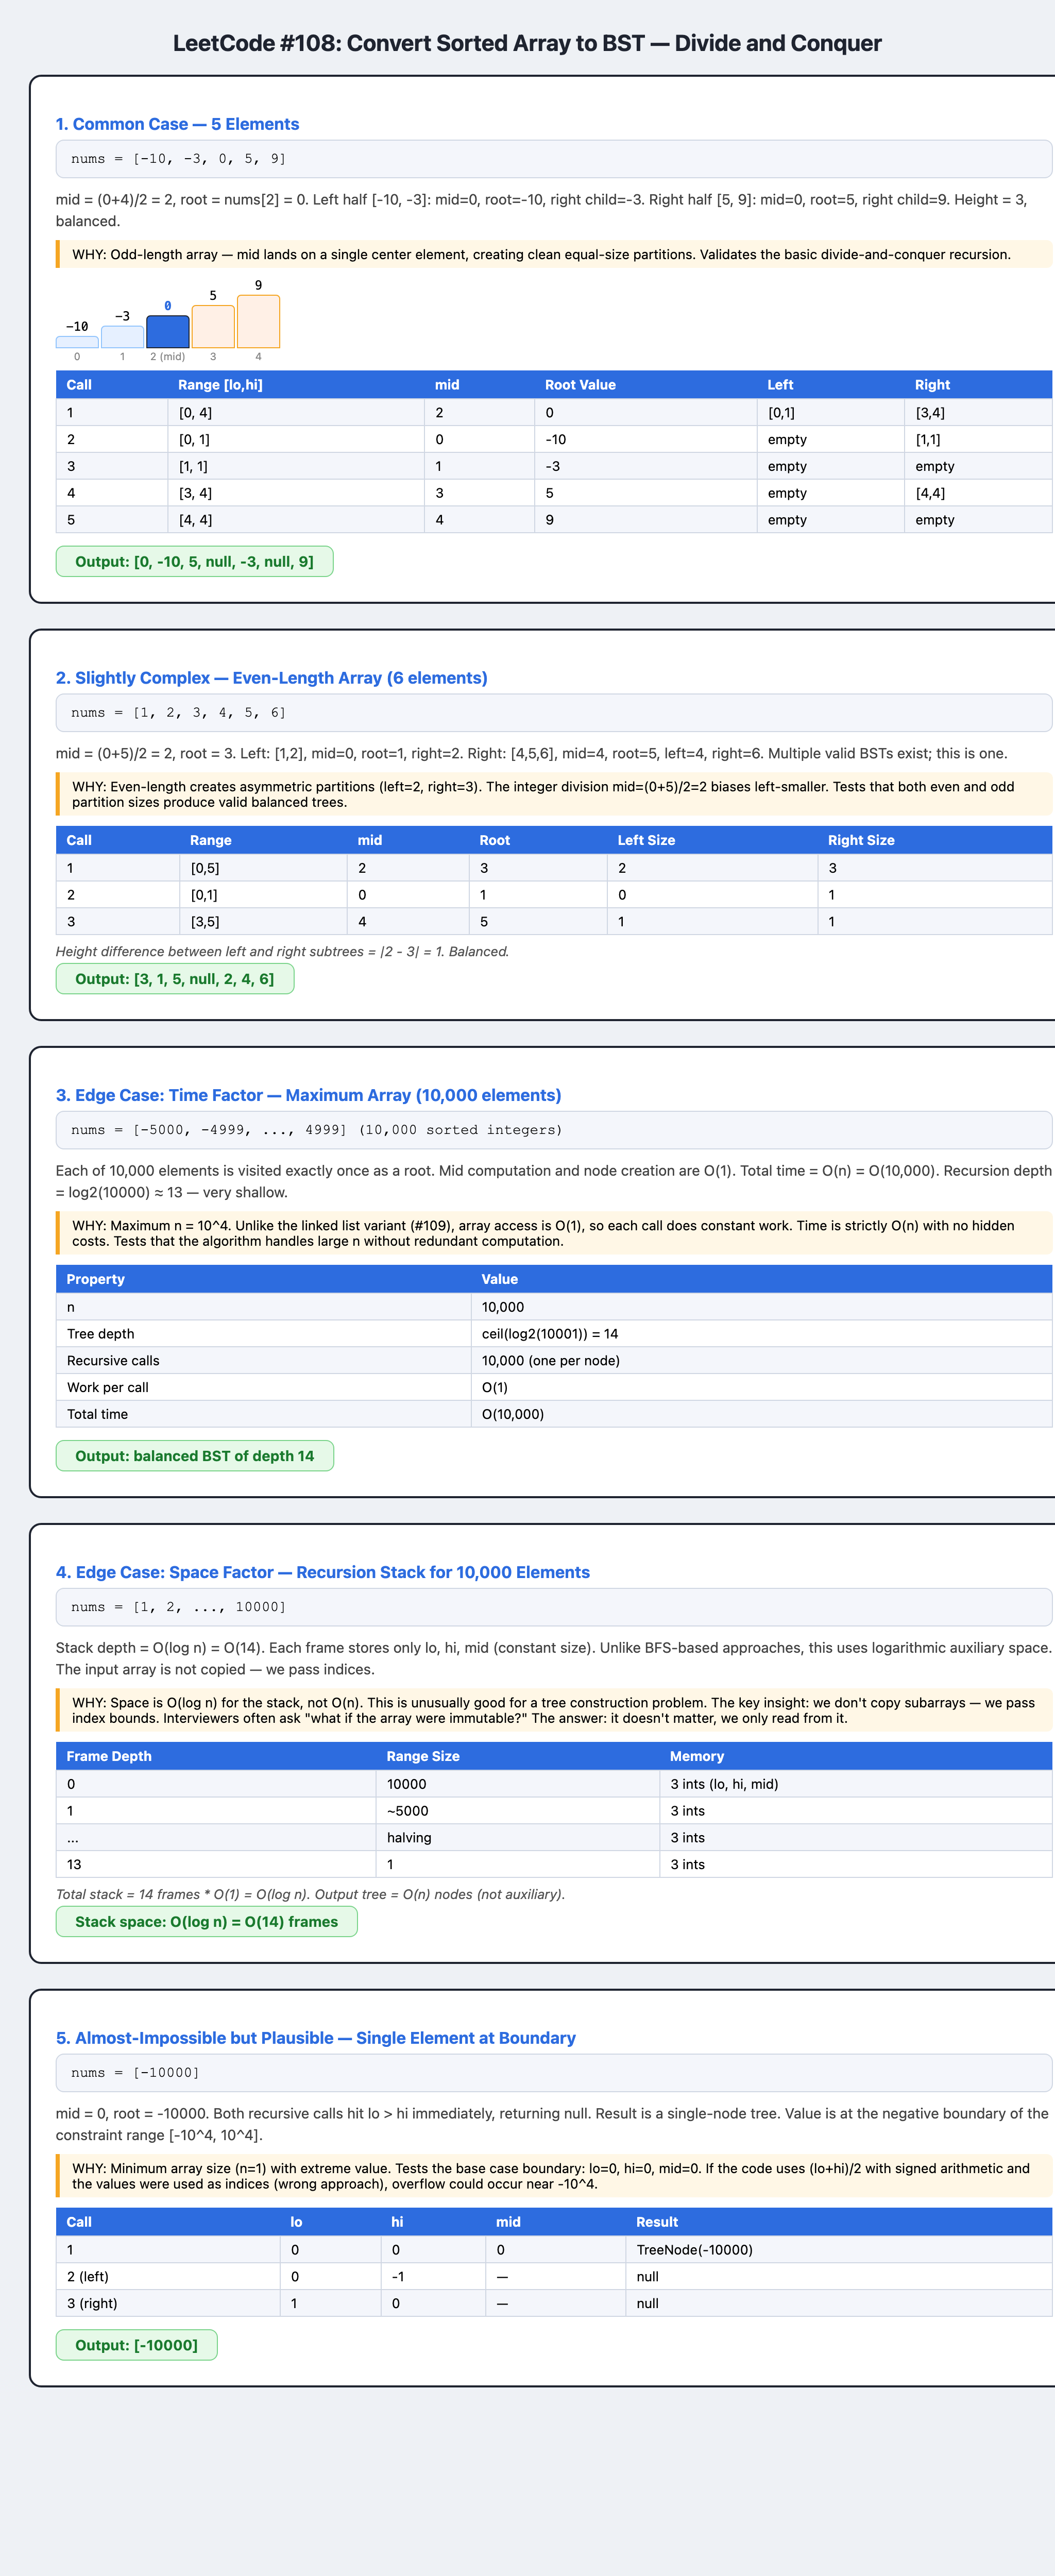